#Подготовка данных

In [ ]:
%pip install torch transformers datasets evaluate scikit-learn accelerate streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 36.3 MB/s eta 0:00:00


In [ ]:
from transformers import pipeline

pipe = pipeline("fill-mask", model="distilbert/distilbert-base-cased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-cased")

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
import kagglehub

path = kagglehub.dataset_download("neelshah18/arxivdataset")
print(path)

Using Colab cache for faster access to the 'arxivdataset' dataset.
/kaggle/input/arxivdataset


In [ ]:
import pandas as pd
import os

csv_path = os.path.join(path, 'arxivData.json')
df = pd.read_json(csv_path)
df.head()

,author,day,id,link,month,summary,tag,title,year
0,"[{'name': 'Ahmed Osman'}, {'name': 'Wojciech S...",1,1802.00209v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",2,We propose an architecture for VQA which utili...,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...",Dual Recurrent Attention Units for Visual Ques...,2018
1,"[{'name': 'Ji Young Lee'}, {'name': 'Franck De...",12,1603.03827v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",3,Recent approaches based on artificial neural n...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Sequential Short-Text Classification with Recu...,2016
2,"[{'name': 'Iulian Vlad Serban'}, {'name': 'Tim...",2,1606.00776v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",6,We introduce the multiresolution recurrent neu...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Multiresolution Recurrent Neural Networks: An ...,2016
3,"[{'name': 'Sebastian Ruder'}, {'name': 'Joachi...",23,1705.08142v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",5,Multi-task learning is motivated by the observ...,"[{'term': 'stat.ML', 'scheme': 'http://arxiv.o...",Learning what to share between loosely related...,2017
4,"[{'name': 'Iulian V. Serban'}, {'name': 'Chinn...",7,1709.02349v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",9,We present MILABOT: a deep reinforcement learn...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",A Deep Reinforcement Learning Chatbot,2017


Вычленим из колонки tag все встречающиеся категории

In [ ]:
import ast

df['tag_parsed'] = df['tag'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

categories = []
for tag_dlist in df['tag_parsed']:
  for tag_dict in tag_dlist:
    if tag_dict['term'] not in categories:
      categories.append(tag_dict['term'])

Сделаем в датафрейме отдельную колонку, куда сохраним все категории, встречающиеся для этой статьи, а также отсортируем странно помеченные категории(не в формате category.subcategory)

In [ ]:
import re

def is_category(cat):
  return bool(re.match(r'^[^.]+\.[^.]+$', cat))

def parse_categories(cat_list):
  categories = []
  for cat_dict in cat_list:
    categories.append(cat_dict['term'])
  return categories


df['state_cats'] = df['tag_parsed'].apply(parse_categories)
df['arxiv_cat'] = df['state_cats'].apply(lambda x: [cat for cat in x if is_category(cat)])
df_cut = df[df['arxiv_cat'].map(len) > 0].copy()
df_cut.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41000 entries, 0 to 40999
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   author      41000 non-null  object
 1   day         41000 non-null  int64 
 2   id          41000 non-null  object
 3   link        41000 non-null  object
 4   month       41000 non-null  int64 
 5   summary     41000 non-null  object
 6   tag         41000 non-null  object
 7   title       41000 non-null  object
 8   year        41000 non-null  int64 
 9   tag_parsed  41000 non-null  object
 10  state_cats  41000 non-null  object
 11  arxiv_cat   41000 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.8+ MB


Посмотрим на распределеление категорий

In [ ]:
import plotly.express as px

exploded = df_cut.explode('arxiv_cat')
cats_counts = exploded['arxiv_cat'].value_counts().reset_index()
px.histogram(cats_counts, x = 'arxiv_cat', y = 'count')

Распределение категорий сильно смещенное

In [ ]:
top_categories = cats_counts.head(40)
top_categories

,arxiv_cat,count
0,cs.CV,13902
1,cs.LG,13735
2,cs.AI,10481
3,stat.ML,10326
4,cs.CL,6417
5,cs.NE,3819
6,cs.IR,1443
7,math.OC,1020
8,cs.RO,973
9,cs.LO,643


Определим категории, на которые будем делить статьи

In [ ]:
def extract_category(cats):
  return list(set([cat.split('.')[0] for cat in cats]))

In [ ]:
categories_list = extract_category(top_categories['arxiv_cat'])
categories_list

['math', 'cs', 'physics', 'q-bio', 'stat']

In [ ]:
df_cut['top_cats'] = df_cut['arxiv_cat'].apply(lambda x: [cat for cat in x if cat in set(top_categories['arxiv_cat'])])
df_cut['label_cat'] = df_cut['top_cats'].apply(extract_category)
df_cut.head()

,author,day,id,link,month,summary,tag,title,year,tag_parsed,state_cats,arxiv_cat,top_cats,label_cat
0,"[{'name': 'Ahmed Osman'}, {'name': 'Wojciech S...",1,1802.00209v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",2,We propose an architecture for VQA which utili...,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...",Dual Recurrent Attention Units for Visual Ques...,2018,"[{'term': 'cs.AI', 'scheme': 'http://arxiv.org...","[cs.AI, cs.CL, cs.CV, cs.NE, stat.ML]","[cs.AI, cs.CL, cs.CV, cs.NE, stat.ML]","[cs.AI, cs.CL, cs.CV, cs.NE, stat.ML]","[cs, stat]"
1,"[{'name': 'Ji Young Lee'}, {'name': 'Franck De...",12,1603.03827v1,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",3,Recent approaches based on artificial neural n...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Sequential Short-Text Classification with Recu...,2016,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs, stat]"
2,"[{'name': 'Iulian Vlad Serban'}, {'name': 'Tim...",2,1606.00776v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",6,We introduce the multiresolution recurrent neu...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",Multiresolution Recurrent Neural Networks: An ...,2016,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML, I.5.1; I...","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs, stat]"
3,"[{'name': 'Sebastian Ruder'}, {'name': 'Joachi...",23,1705.08142v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",5,Multi-task learning is motivated by the observ...,"[{'term': 'stat.ML', 'scheme': 'http://arxiv.o...",Learning what to share between loosely related...,2017,"[{'term': 'stat.ML', 'scheme': 'http://arxiv.o...","[stat.ML, cs.AI, cs.CL, cs.LG, cs.NE]","[stat.ML, cs.AI, cs.CL, cs.LG, cs.NE]","[stat.ML, cs.AI, cs.CL, cs.LG, cs.NE]","[cs, stat]"
4,"[{'name': 'Iulian V. Serban'}, {'name': 'Chinn...",7,1709.02349v2,"[{'rel': 'alternate', 'href': 'http://arxiv.or...",9,We present MILABOT: a deep reinforcement learn...,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...",A Deep Reinforcement Learning Chatbot,2017,"[{'term': 'cs.CL', 'scheme': 'http://arxiv.org...","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML, I.5.1; I...","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs.CL, cs.AI, cs.LG, cs.NE, stat.ML]","[cs, stat]"


In [ ]:
df_cut['text'] = df_cut['title'].str.strip() + '. ' + df_cut['summary'].str.strip()

In [ ]:
def encode_labels(cats_list, classes):
  return [1 if cat in cats_list else 0 for cat in classes]


In [ ]:
id_to_label = {}
for i, cat in enumerate(categories_list):
  id_to_label[i] = cat
id_to_label

{0: 'math', 1: 'cs', 2: 'physics', 3: 'q-bio', 4: 'stat'}

In [ ]:
label_to_id = {label : id for id, label in id_to_label.items()}

df_cut['label'] = df_cut['label_cat'].apply(lambda x: encode_labels(x, categories_list))
data = df_cut[['text', 'label']].reset_index(drop=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41000 entries, 0 to 40999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    41000 non-null  object
 1   label   41000 non-null  object
dtypes: object(2)
memory usage: 640.8+ KB


In [ ]:
from sklearn.model_selection import train_test_split

data = data.sample(n=10000, random_state=42).reset_index(drop=True)

train_df, t_v_df = train_test_split(data, test_size=0.2)
val_df, test_df = train_test_split(t_v_df, test_size=0.5)

In [ ]:
from datasets import Dataset, DatasetDict
ds = DatasetDict({
    'train':      Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df,   preserve_index=False),
    'test':       Dataset.from_pandas(test_df,  preserve_index=False),
})

In [ ]:
def tokenize_function(examples):
    tokenized_inputs = tokenizer(examples['text'], truncation=True, max_length=256)
    tokenized_inputs["labels"] = [list(map(float, label_list)) for label_list in examples["label"]]
    return tokenized_inputs

tokenized = ds.map(tokenize_function, batched=True, batch_size=1000)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

In [ ]:
tokenized["train"][0].keys()

dict_keys(['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

#Запуск DistilBert

In [ ]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

train_dataset = tokenized['train'].shuffle(seed=42)
eval_dataset  = tokenized['validation'].shuffle(seed=42)

train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
eval_dataset.set_format(type='torch',  columns=['input_ids', 'attention_mask', 'labels'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
dataloader = DataLoader(train_dataset, batch_size=4, collate_fn=data_collator)
res = next(iter(dataloader))

for key, value in res.items():
    print(key, value.shape, value, sep="\n", end="\n-------\n")

input_ids
torch.Size([4, 256])
tensor([[  101,  8060,   118,  ...,  1211,  2530,   102],
        [  101,  7993,   148,  ...,     0,     0,     0],
        [  101, 18447, 17482,  ...,     0,     0,     0],
        [  101, 11896,  1584,  ..., 18922,  1108,   102]])
-------
attention_mask
torch.Size([4, 256])
tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1]])
-------
labels
torch.Size([4, 5])
tensor([[0., 1., 0., 0., 0.],
        [0., 1., 0., 0., 1.],
        [0., 1., 0., 0., 1.],
        [0., 1., 0., 0., 0.]])
-------


зададим модель и параметры

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    'distilbert-base-cased',
    num_labels=len(categories_list),
    id2label=id_to_label,
    label2id=label_to_id,
    problem_type="multi_label_classification"
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
from transformers import Trainer, TrainingArguments
training_args = TrainingArguments(
    output_dir="./my_model",
    num_train_epochs=5,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=1,
    log_level="error",
    logging_dir="output_dir/runs/CURRENT_DATETIME_HOSTNAME",
    logging_strategy="steps",
    logging_steps=50,
    save_strategy="epoch",
    # save_steps=1,
    save_total_limit=2,
    # save_safetensors=True,
    save_only_model=False,
    use_cpu=False,
    seed=42,
    # bf16=True,  # использовать bf16 вместо fp32
    eval_strategy="epoch",
    # eval_steps=32,
    disable_tqdm=False,
    load_best_model_at_end=True,
    metric_for_best_model = "f1_macro",
    label_smoothing_factor=0.,
    weight_decay=0.01,
    optim="adamw_torch",
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Будем вычислять 3 метрики f1_macro, f1_micro и accuracy

In [ ]:
import numpy as np
import torch
from sklearn.metrics import f1_score, accuracy_score

def compute_metrics(eval_pred):
  logits, labels = eval_pred

  probs = torch.sigmoid(torch.tensor(logits)).numpy()
  preds = (probs > 0.5).astype(int)

  labels_int = labels.astype(int)

  return {
      'f1_macro' : f1_score(labels, preds, average='macro', zero_division=0),
      'f1_micro' : f1_score(labels, preds, average='micro', zero_division=0),
      'accuracy' : accuracy_score(labels, preds),
  }

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
    data_collator = data_collator,
)

trainer.train()

Epoch,Training Loss,Validation Loss,F1 Macro,F1 Micro,Accuracy
1,0.174674,0.183505,0.322570,0.870993,0.696000
2,0.146601,0.166420,0.330596,0.877916,0.706000
3,0.134404,0.165071,0.396647,0.879317,0.713000
4,0.107285,0.167810,0.465913,0.880925,0.717000
5,0.101517,0.169257,0.449038,0.878917,0.713000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1250, training_loss=0.16023834686279298, metrics={'train_runtime': 1145.4602, 'train_samples_per_second': 34.92, 'train_steps_per_second': 1.091, 'total_flos': 2649489715200000.0, 'train_loss': 0.16023834686279298, 'epoch': 5.0})

Проверим, насколько метрики изменяться, если поменять порог классификации

In [ ]:
val_logits = trainer.predict(eval_dataset).predictions
val_labels = np.array(eval_dataset["labels"]).astype(int)
val_probs = torch.sigmoid(torch.tensor(val_logits)).numpy()
scores_micro = []
scores_macro = []
scores_acc = []

for t in np.arange(0.1, 0.6, 0.05):
    preds = (val_probs > t).astype(int)
    scores_micro.append(f1_score(val_labels, preds, average='micro', zero_division=0))
    scores_macro.append(f1_score(val_labels, preds, average='macro', zero_division=0))
    scores_acc.append(accuracy_score(val_labels, preds))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

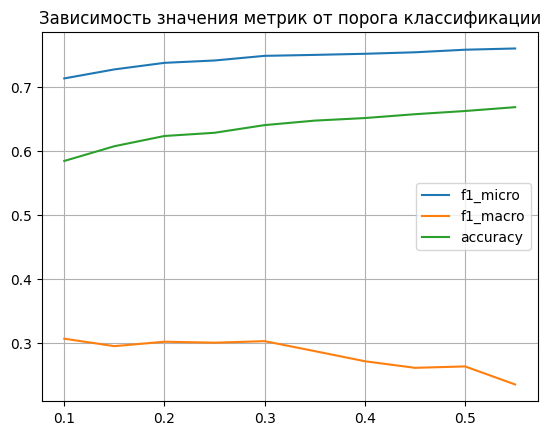

In [ ]:
import matplotlib.pyplot as plt
plt.plot(np.arange(0.1, 0.6, 0.05), scores_micro, label='f1_micro')
plt.plot(np.arange(0.1, 0.6, 0.05), scores_macro, label='f1_macro')
plt.plot(np.arange(0.1, 0.6, 0.05), scores_acc, label='accuracy')
plt.legend()
plt.grid(True)
plt.title('Зависимость значения метрик от порога классификации')
plt.show()

Как видно из графика, оптимальным брать порог примерно 0.3

Сохраним модель на HF

In [ ]:
trainer.save_model("./final_model")
tokenizer.save_pretrained("./final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./final_model/tokenizer_config.json', './final_model/tokenizer.json')

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained("./final_model")
tokenizer = AutoTokenizer.from_pretrained("./final_model")

texts = ["statistical properties of models. This paper explores statistical properties of models", "Deep learning for NLP. This paper explores transformers"]

tokens_info = tokenizer(texts, return_tensors="pt", truncation=True, padding=True)

model.eval()
model.cpu()
with torch.no_grad():
    out = model(**tokens_info)
    probs = torch.sigmoid(out.logits)

    for i, (text, prob_tensor) in enumerate(zip(texts, probs.tolist())):
        print(f"Text: `{text}`")
        category_names = [model.config.id2label[j] for j in range(len(prob_tensor))]
        prediction_info = []
        for j, prob in enumerate(prob_tensor):
            prediction_info.append(f"{category_names[j]}={prob:.3f}")
        print(f"Предсказание: {'; '.join(prediction_info)}\n")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text: `statistical properties of models. This paper explores statistical properties of models`
Предсказание: math=0.073; cs=0.902; stat=0.578; physics=0.015; q-bio=0.016

Text: `Deep learning for NLP. This paper explores transformers`
Предсказание: math=0.036; cs=0.982; stat=0.322; physics=0.008; q-bio=0.010



In [ ]:
!pip install huggingface_hub

In [ ]:
from huggingface_hub import notebook_login

notebook_login()
!huggingface-cli login

/bin/bash: line 1: huggingface-cli: command not found


In [ ]:
model.push_to_hub("glegor/arxiv-classifier")
tokenizer.push_to_hub("glegor/arxiv-classifier")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...0w46z15/model.safetensors:   0%|          |  564kB /  263MB            

README.md: 0.00B [00:00, ?B/s]

CommitInfo(commit_url='https://huggingface.co/glegor/arxiv-classifier/commit/a86b99f5997979d374cf0a3a0ee06fca27214a06', commit_message='Upload tokenizer', commit_description='', oid='a86b99f5997979d374cf0a3a0ee06fca27214a06', pr_url=None, repo_url=RepoUrl('https://huggingface.co/glegor/arxiv-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='glegor/arxiv-classifier'), pr_revision=None, pr_num=None)

#Датасет permutans/arxiv-papers-by-subject

In [ ]:
from datasets import load_dataset, DownloadConfig
from collections import defaultdict
import re

download_config = DownloadConfig(max_retries=100, resume_download=True)

ds = load_dataset(
    "permutans/arxiv-papers-by-subject",
    split="train",
    streaming=True,
    download_config = download_config
).select_columns(["title", "abstract", "primary_subject", "subjects"])



Resolving data files:   0%|          | 0/42776 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/42776 [00:00<?, ?it/s]

In [ ]:
def extract_tag(subject_str):
    match = re.search(r'\(([^)]+)\)', subject_str)
    return match.group(1) if match else subject_str.strip()

classes_counts = defaultdict(int)
taken = []
seen = set()
classes = 15
classes_size = 2000

shuffled_ds = ds.shuffle(buffer_size=100_000, seed=42)



ValueError: not enough values to unpack (expected 2, got 1)

In [ ]:
for row in shuffled_ds:
  extracted_tag = extract_tag(row["primary_subject"])
  if '.' in extracted_tag:
    tag, subtag = extracted_tag.split('.')
  else:
    tag = extracted_tag
  if len(seen) == classes and tag not in seen:
    continue
  seen.add(tag)
  if classes_counts[tag] < classes_size:
    taken.append(row)
    classes_counts[tag] += 1
  if len([c for c in classes_counts.values() if c == classes_size]) == classes:
    break

KeyboardInterrupt: 

In [ ]:
print(f"Всего отобрано: {len(taken)} примеров.")
for tag, count in classes_counts.items():
    print(f"Для тэга {tag} собрано {count} примеров")

Всего отобрано: 29476 примеров.
Для тэга math собрано 2000 примеров
Для тэга cs собрано 2000 примеров
Для тэга nucl-th собрано 2000 примеров
Для тэга cond-mat собрано 2000 примеров
Для тэга quant-ph собрано 2000 примеров
Для тэга physics собрано 2000 примеров
Для тэга q-bio собрано 2000 примеров
Для тэга hep-th собрано 2000 примеров
Для тэга econ собрано 1615 примеров
Для тэга nucl-ex собрано 1861 примеров
Для тэга stat собрано 2000 примеров
Для тэга hep-ph собрано 2000 примеров
Для тэга gr-qc собрано 2000 примеров
Для тэга hep-ex собрано 2000 примеров
Для тэга astro-ph собрано 2000 примеров


In [ ]:
def extract_name(subject_str):
    return re.sub(r'\s*\([^)]+\)', '', subject_str).strip()

tag_to_name = {}
for row in taken:
    tag = extract_tag(row['primary_subject'])
    name = extract_name(row['primary_subject'])
    if tag not in tag_to_name:
        tag_to_name[tag] = name

In [ ]:
tag_to_name

{'math.PR': 'Probability',
 'cs.GR': 'Graphics',
 'cs.LG': 'Machine Learning',
 'nucl-th': 'Nuclear Theory',
 'math.DS': 'Dynamical Systems',
 'cs.RO': 'Robotics',
 'cs.AI': 'Artificial Intelligence',
 'math.RT': 'Representation Theory',
 'cs.CL': 'Computation and Language',
 'cond-mat.mtrl-sci': 'Materials Science',
 'math.NT': 'Number Theory',
 'quant-ph': 'Quantum Physics',
 'math.CO': 'Combinatorics',
 'physics.atom-ph': 'Atomic Physics',
 'physics.optics': 'Optics',
 'q-bio.MN': 'Molecular Networks',
 'cond-mat.str-el': 'Strongly Correlated Electrons',
 'math.AP': 'Analysis of PDEs',
 'cs.CV': 'Computer Vision and Pattern Recognition',
 'cs.NI': 'Networking and Internet Architecture',
 'hep-th': 'High Energy Physics - Theory',
 'q-bio.NC': 'Neurons and Cognition',
 'econ.GN': 'General Economics',
 'cond-mat.mes-hall': 'Mesoscale and Nanoscale Physics',
 'nucl-ex': 'Nuclear Experiment',
 'stat.ML': 'Machine Learning',
 'math.DG': 'Differential Geometry',
 'cond-mat.stat-mech': 'Sta

In [ ]:
tag_to_idx = {tag: i for i, tag in enumerate(sorted(seen))}
idx_to_tag = {i: tag for tag, i in tag_to_idx.items()}

In [ ]:
classes_count = len(seen)

In [ ]:
def prepare(example):
    text = (example["title"] or "") + '. ' + (example["abstract"] or "")

    raw = example["subjects"]
    subjects_list = raw if isinstance(raw, list) else [raw]

    tags = [extract_tag(s) for s in subjects_list]

    label = [0.0] * classes_count
    for tag in tags:
        if tag in tag_to_idx:
            label[tag_to_idx[tag]] = 1.0

    return {"text": text, "label": label}

ds_prepared = ds.map(prepare, remove_columns=["title", "abstract", "primary_subject", "subjects"])

In [ ]:
from datasets import Dataset, DatasetDict
dataset = Dataset.from_list(seen)

In [ ]:
dataset[0]

{'title': 'ARCADE 2 Measurement of the Extra-Galactic Sky Temperature at 3-90 GHz',
 'abstract': 'The ARCADE 2 instrument has measured the absolute temperature of the sky at frequencies 3, 8, 10, 30, and 90 GHz, using an open-aperture cryogenic instrument observing at balloon altitudes with no emissive windows between the beam-forming optics and the sky. An external blackbody calibrator provides an {\\it in situ} reference. Systematic errors were greatly reduced by using differential radiometers and cooling all critical components to physical temperatures approximating the CMB temperature. A linear model is used to compare the output of each radiometer to a set of thermometers on the instrument. Small corrections are made for the residual emission from the flight train, balloon, atmosphere, and foreground Galactic emission. The ARCADE 2 data alone show an extragalactic rise of $50\\pm7$ mK at 3.3 GHz in addition to a CMB temperature of $2.730\\pm .004$ K. Combining the ARCADE 2 data wi